# Belgium netherlands

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image
from tqdm import tqdm
import pandas as pd
import os

In [2]:
# Cell: Set Global Seeds for Reproducibility

import random

# Define a single seed value to be used across the notebook
GLOBAL_SEED = 42

# Set the seed for numpy's random number generator
np.random.seed(GLOBAL_SEED)

# Set the seed for Python's built-in random module
random.seed(GLOBAL_SEED)

print(f"Global random seeds set to {GLOBAL_SEED} for reproducibility.")

Global random seeds set to 42 for reproducibility.


In [3]:
def add_watermark(ax):
        """Helper to add watermark to a plot."""
        ax.text(0.95, 0.95, "harshit.goyal",
                ha='right', va='top',
                transform=ax.transAxes,
                fontsize=10, color='gray', alpha=0.7)

## 1.1

### Binary Masks Conversion

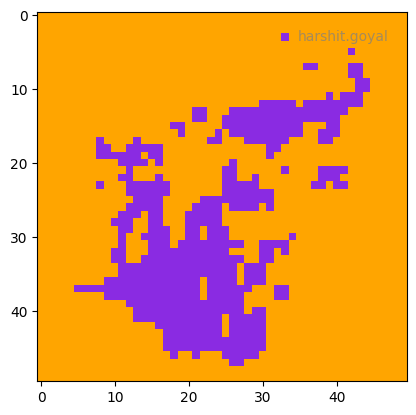

In [4]:
img= Image.open('./Q1/border.png')
add_watermark(plt.gca())
plt.imshow(img)

In [5]:
img_arr = np.array(img)
print(img_arr.shape)
unique_colors = np.unique(img_arr.reshape(-1, 3), axis=0)
print(f"Unique colors (RGB): {unique_colors}")

(50, 50, 3)
Unique colors (RGB): [[138  43 226]
 [255 165   0]]


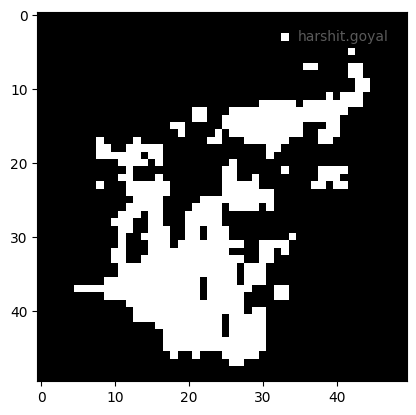

In [6]:
for i in range(img_arr.shape[0]):
    for j in range(img_arr.shape[1]):
        if np.array_equal(img_arr[i,j],unique_colors[0]):
            img_arr[i,j] = [255,255,255]
        else:
            img_arr[i,j] = [0,0,0]
add_watermark(plt.gca())
plt.imshow(img_arr)

### Dataset Class

In [7]:
class Dataset:
    def __init__(self, img_arr, seed=42):
        self.img_arr = img_arr
        rng = np.random.default_rng(seed)
        pixel_list = []
        
        # Handle both 2D and 3D arrays
        if len(img_arr.shape) == 3:
            self.height, self.width, _ = img_arr.shape
        elif len(img_arr.shape) == 2:
            self.height, self.width = img_arr.shape
        else:
            raise ValueError("img_arr must be a 2D or 3D array")
        
        for y in range(self.height):
            for x in range(self.width):
                norm_x = y / self.height
                norm_y = x / self.width
                label = 1 if img_arr[y, x] > 0 else 0
                pixel_list.append([norm_x, norm_y, label])
        
        self.shuffled_pixels = np.array(pixel_list, dtype=np.float32)
        rng.shuffle(self.shuffled_pixels)

    def get_all_data(self):
        return self.shuffled_pixels

In [8]:
binary_mask = (img_arr[:,:,0] > 0).astype(np.uint8)
print(binary_mask.shape)
# plt.imshow(binary_mask, cmap='gray')

(50, 50)


In [9]:
dataset_obj = Dataset(binary_mask)
final_data = dataset_obj.get_all_data()
print(final_data.shape)
print(final_data[:5])

(2500, 3)
[[0.22 0.14 0.  ]
 [0.66 0.62 1.  ]
 [0.1  0.14 0.  ]
 [0.54 0.76 0.  ]
 [0.62 0.14 0.  ]]


## 1.2

### Neural Network Implementation

In [ ]:
class LinearLayer:
    def __init__(self,input_dim,output_dim,activation,seed=42):
        self.input_dim = input_dim
        self.output_dim = output_dim
        np.random.seed(seed)
        self.activation = activation
        self.weights = np.random.randn(input_dim,output_dim) * np.sqrt(2. / input_dim)
        self.bias = np.zeros((1,output_dim))
        self.dW = np.zeros_like(self.weights)
        self.db = np.zeros_like(self.bias)

    def forward(self,X):
        self.input = X 
        self.z = np.dot(X,self.weights) + self.bias
        self.a = self.activation.forward(self.z)
        self.output = self.a
        return self.output
    
    def backward(self,out_grad):
        dZ = out_grad * self.activation.backward(self.z)
        batch_size = self.input.shape[0]
        dW_batch = np.dot(self.input.T, dZ) / batch_size
        db_batch = np.sum(dZ, axis=0, keepdims=True) / batch_size
        self.dW += dW_batch
        self.db += db_batch
        in_grad = np.dot(dZ, self.weights.T)
        return in_grad

### Activation classes 

In [11]:
class ReLU:
    def __init__(self):
        pass

    def forward(self,x):
        return np.maximum(0,x)

    def backward(self,x):
        grad = np.where(x > 0, 1, 0)
        return grad

In [12]:
class Tanh:
    def __init__(self):
        pass

    def forward(self,x):
        return np.tanh(x)

    def backward(self,x):
        return 1 - np.tanh(x)**2

In [13]:
class Sigmoid:
    def __init__(self):
        pass

    def forward(self,x):
        return 1 / (1 + np.exp(-x))

    def backward(self,x):
        sig = self.forward(x)
        return sig * (1 - sig)

In [14]:
class Identity:
    def __init__(self):
        pass

    def forward(self,x):
        return x

    def backward(self,x):
        return np.ones_like(x)

### Loss Function Classes

#### MSE

In [15]:
class mse:

    def __init__(self):
        pass

    def err(self,y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def der(self,y_true, y_pred):
        return 2 * (y_pred - y_true) / y_true.size  

#### BCE

In [16]:
EPSILON = 1e-9

class bce:
    
    def __init__(self):
        pass
    def err(self,y_true, y_pred):
        """Calculates Binary Cross-Entropy loss."""
        # Clip predictions to avoid log(0) error
        y_pred_clipped = np.clip(y_pred, EPSILON, 1 - EPSILON)
        return -np.mean(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))

    def der(self,y_true, y_pred):
        """Calculates the derivative of BCE loss."""
        # Clip predictions to avoid division by zero
        y_pred_clipped = np.clip(y_pred, EPSILON, 1 - EPSILON)
        return - (y_true / y_pred_clipped - (1 - y_true) / (1 - y_pred_clipped)) / np.size(y_true)

### Model

In [17]:
class Model:
    def __init__(self,layers,loss,lr=0.01):
        self.layers = layers
        self.loss = loss
        self.lr = lr
    
    def train(self,x,y):
        for layer in self.layers:
            x = layer.forward(x)
        loss_value = self.loss.err(y, x)
        grad = self.loss.der(y, x)
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return loss_value
    
    def zero_grad(self):
        for layer in self.layers:
            layer.dW.fill(0)
            layer.db.fill(0)

    def update(self):
        for layer in self.layers:
            layer.weights -= self.lr * layer.dW
            layer.bias -= self.lr * layer.db
        self.zero_grad()

    def predict(self,x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def save_to(self, path):
        """Saves all model parameters (weights and biases) to a .npz file."""
        params_to_save = {}
        for i, layer in enumerate(self.layers):
            # Only save parameters for layers that have them (like Linear)
            if hasattr(layer, 'weights'):
                params_to_save[f"layer_{i}_weights"] = layer.weights
                params_to_save[f"layer_{i}_bias"] = layer.bias
        
        np.savez(path, **params_to_save)
        print(f"Model saved to {path}")
    
    def load_from(self, path):
        """
        Loads model parameters from a .npz file.
        Throws an error if the architecture does not match.
        """
        if not os.path.exists(path):
            raise FileNotFoundError(f"No model file found at {path}")
            
        data = np.load(path, allow_pickle=True)
        
        for i, layer in enumerate(self.layers):
            if hasattr(layer, 'weights'):
                # Construct the keys for weights and bias for the current layer
                weights_key = f"layer_{i}_weights"
                bias_key = f"layer_{i}_bias"
                
                # Check if the keys exist in the saved file
                if weights_key not in data or bias_key not in data:
                    raise ValueError(f"Parameters for layer {i} not found in the file.")
                
                # Check if shapes match the current model architecture
                if layer.weights.shape != data[weights_key].shape:
                    raise ValueError(f"Shape mismatch for weights in layer {i}. "
                                     f"Model: {layer.weights.shape}, File: {data[weights_key].shape}")
                if layer.bias.shape != data[bias_key].shape:
                    raise ValueError(f"Shape mismatch for bias in layer {i}. "
                                     f"Model: {layer.bias.shape}, File: {data[bias_key].shape}")
                
                # If everything matches, load the parameters
                layer.weights = data[weights_key]
                layer.bias = data[bias_key]
                
        print(f"Model loaded successfully from {path}")

### Training procedure

In [18]:
def train_loop(model, data, epochs=32, batch_size=32, grad_accumulation_steps=1):
    """
    Train the model using the provided data with improved progress tracking.

    Parameters:
    - model: The neural network model to train.
    - data: The dataset to train on, expected to be a numpy array with features and labels.
    - epochs: Number of training epochs.
    - batch_size: Number of samples per batch.
    - grad_accumulation_steps: Number of steps to accumulate gradients before updating parameters.
    """
    num_batches = int(np.ceil(data.shape[0] / batch_size))
    total_samples = 0
    
    # Lists to store data for the final plot
    losses_per_epoch = []
    samples_seen_per_epoch = []

    print("Starting model training...")

    # Outer loop for epochs with a tqdm progress bar
    for epoch in tqdm(range(epochs), desc="Overall Progress"):
        epoch_loss = 0.0
        
        # Inner loop for batches. `leave=False` makes the bar disappear after completion.
        # This keeps the console clean.
        batch_pbar = tqdm(range(num_batches), desc=f"Epoch {epoch + 1}/{epochs}", leave=False)

        for batch_idx in batch_pbar:
            # Get the batch data
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, data.shape[0])
            batch_data = data[start_idx:end_idx]

            # Separate features and labels
            x_batch = batch_data[:, :-1]  # All columns except the last
            y_batch = batch_data[:, -1:]  # The last column

            # Forward and backward pass
            loss = model.train(x_batch, y_batch)
            epoch_loss += loss

            # Accumulate gradients and update parameters
            if (batch_idx + 1) % grad_accumulation_steps == 0 or (batch_idx + 1) == num_batches:
                model.update()
            
            # Track the total number of samples seen
            total_samples += x_batch.shape[0]

        # Calculate and store the average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        losses_per_epoch.append(avg_epoch_loss)
        samples_seen_per_epoch.append(total_samples)

        # Print the average loss every 50 epochs, or on the last epoch
        if (epoch + 1) % 50 == 0 or (epoch + 1) == epochs:
            # Use tqdm.write to print messages without disturbing the progress bars
            tqdm.write(f"Epoch {epoch + 1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}")

    print("\nTraining complete.")

    # --- Plotting and Saving ---
    plt.figure(figsize=(10, 6))
    plt.plot(samples_seen_per_epoch, losses_per_epoch, marker='o', linestyle='-', label="Training Loss per Epoch")
    plt.xlabel("Number of Samples Seen")
    plt.ylabel("Average Loss")
    plt.title("Training Loss vs. Samples Seen")
    plt.legend()
    add_watermark(plt.gca())
    plt.grid(True)

    # Create a unique folder for this run
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_folder = os.path.join("runs", timestamp)
    os.makedirs(run_folder, exist_ok=True)

    # Save the plot
    plot_path = os.path.join(run_folder, "training_loss.png")
    plt.savefig(plot_path)
    print(f"Training loss plot saved to {plot_path}")

    # Save the model parameters
    model_path = os.path.join(run_folder, "final_model.npz")
    model.save_to(model_path)

### Early Stopping 


In [19]:
def train_loop_early_stop(model, data, epochs=1000, batch_size=32, grad_accumulation_steps=1,
               patience=10, relative_loss_threshold=0.01, early_stopping=True):
    """
    Train the model using the provided data with early stopping support.
    """
    num_batches = int(np.ceil(data.shape[0] / batch_size))
    total_samples = 0  # Track total samples processed
    
    # Lists to store data for the final plot
    losses_per_epoch = []
    samples_seen_per_epoch = []
    
    # Early stopping variables
    stopped_early = False
    stop_epoch = None

    print("Starting model training...")
    print(f"Early Stopping: {'Enabled' if early_stopping else 'Disabled'}")
    if early_stopping:
        print(f"  - Patience: {patience} epochs")
        print(f"  - Relative Loss Threshold: {relative_loss_threshold * 100}%")

    # Outer loop for epochs with a tqdm progress bar
    for epoch in tqdm(range(epochs), desc="Overall Progress"):
        epoch_loss = 0.0
        
        # Inner loop for batches
        for batch_idx in range(num_batches):
            # Get the batch data
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, data.shape[0])
            batch_data = data[start_idx:end_idx]

            # Separate features and labels
            x_batch = batch_data[:, :-1]  # All columns except the last
            y_batch = batch_data[:, -1:]  # The last column

            # Forward and backward pass
            loss = model.train(x_batch, y_batch)
            epoch_loss += loss

            # Accumulate gradients and update parameters
            if (batch_idx + 1) % grad_accumulation_steps == 0 or (batch_idx + 1) == num_batches:
                model.update()
            
            # Track the total number of samples seen
            total_samples += x_batch.shape[0]

        # Calculate and store the average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        losses_per_epoch.append(avg_epoch_loss)
        samples_seen_per_epoch.append(total_samples)

        # Print the average loss every 50 epochs, or on the last epoch
        # if (epoch + 1) % 50 == 0 or (epoch + 1) == epochs:
        #     tqdm.write(f"Epoch {epoch + 1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Early stopping logic
        if early_stopping and epoch >= patience:
            loss_t = avg_epoch_loss
            loss_t_minus_patience = losses_per_epoch[epoch - patience]
            improvement_percent = ((loss_t_minus_patience - loss_t) / loss_t_minus_patience) * 100
            
            if improvement_percent > 0 and improvement_percent < relative_loss_threshold * 100:
                stopped_early = True
                stop_epoch = epoch + 1
                print("\nEarly stopping triggered!")
                print(f"Stopped at epoch: {stop_epoch}")
                print(f"Loss at epoch {stop_epoch}: {loss_t:.4f}")
                print(f"Loss at epoch {stop_epoch - patience}: {loss_t_minus_patience:.4f}")
                print(f"Improvement: {improvement_percent:.2f}% (below threshold of {relative_loss_threshold * 100}%)")
                break

    if not stopped_early:
        print("\nTraining completed without early stopping.")

    return total_samples  # Return total samples processed

## 1.3

### 1.3.1


In [20]:
# Create XOR dataset
# XOR truth table: Input (x1, x2) -> Output (x1 XOR x2)
xor_data = np.array([
    [0, 0, 0],  
    [0, 1, 1],  
    [1, 0, 1],  
    [1, 1, 0]   
], dtype=np.float32)

rng = np.random.default_rng(seed=42)
rng.shuffle(xor_data)

# Display the shuffled XOR dataset
print("Shuffled XOR Dataset:")
print(xor_data)

Shuffled XOR Dataset:
[[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]]


Starting model training...


Overall Progress:   3%|▎         | 30/1000 [00:00<00:03, 291.26it/s]

Epoch 50/1000, Average Loss: 0.5810


Overall Progress:   9%|▉         | 90/1000 [00:00<00:03, 276.55it/s]

Epoch 100/1000, Average Loss: 0.5473


...

Epoch 900/1000, Average Loss: 0.2963


Overall Progress:  94%|█████████▎| 935/1000 [00:03<00:00, 233.07it/s]

Epoch 950/1000, Average Loss: 0.2713


Overall Progress: 100%|██████████| 1000/1000 [00:04<00:00, 241.43it/s]


Epoch 1000/1000, Average Loss: 0.2483

Training complete.
Training loss plot saved to runs\20251015_230930\training_loss.png
Model saved to runs\20251015_230930\final_model.npz


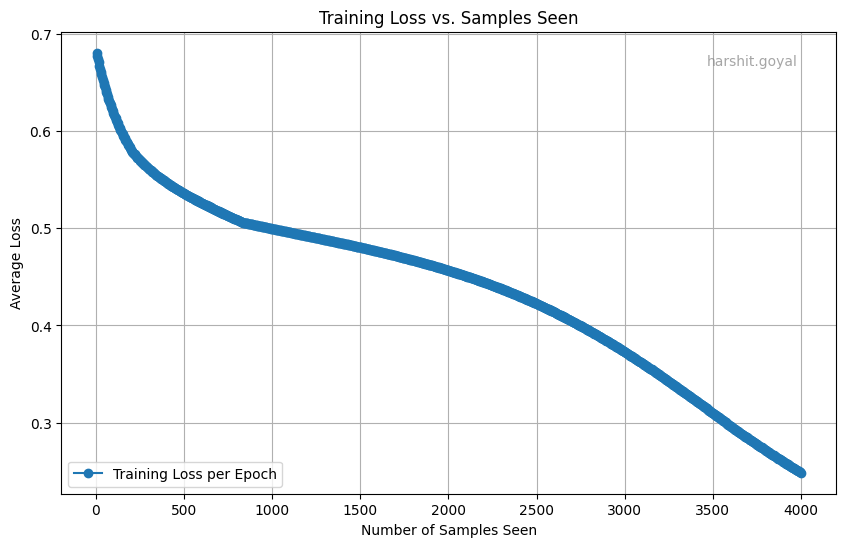

In [21]:
layers = [LinearLayer(2,8,ReLU()),LinearLayer(8,1,Sigmoid())]
model = Model(layers,bce(),lr=0.1)
train_loop(model, xor_data, epochs=1000, batch_size=4, grad_accumulation_steps=1)

In [22]:
y_trues = []
y_preds_bin = []
for point in xor_data:
    x_input = point[:-1].reshape(1, -1)  # Extract input features and reshape for prediction
    y_true = point[-1]  # Extract the true label
    y_pred = model.predict(x_input)  # Get the model's prediction
    y_pred_binary = 1 if y_pred > 0.5 else 0  # Convert prediction to binary (0 or 1)

    print(f"Input: {x_input.flatten()}, True Label: {y_true}, Predicted: {y_pred_binary}, also prediction is {y_pred}")
    y_trues.append(y_true)
    y_preds_bin.append(y_pred_binary)

# Calculate total accuracy
accuracy = np.mean(np.array(y_trues) == np.array(y_preds_bin)) * 100
print(f"Total Accuracy: {accuracy:.2f}%")

Input: [1. 1.], True Label: 0.0, Predicted: 0, also prediction is [[0.26200837]]
Input: [1. 0.], True Label: 1.0, Predicted: 1, also prediction is [[0.96594689]]
Input: [0. 1.], True Label: 1.0, Predicted: 1, also prediction is [[0.70467228]]
Input: [0. 0.], True Label: 0.0, Predicted: 0, also prediction is [[0.26181427]]
Total Accuracy: 100.00%


BCE GIVES 100% accuracy while mse does not which can be explained by the formula of the loss functions.
Loss approaches 0 as prediction approaches correct label
Loss approaches ∞ as prediction approaches wrong label
Strong gradients when prediction is wrong
Weak gradients when prediction is correct
MSE (Mean Squared Error):

Formula: (y - p)²

Gradient: 2(p - y)

Behavior:
Loss is quadratic
Weaker gradients when prediction is very wrong
Can get "stuck" in local minima


### 1.3.2

In [23]:
def gradient_check(model, x, y, epsilon=1e-5):
    """
    Perform gradient checking to verify backpropagation gradients.
    
    Parameters:
    - model: The trained model.
    - x: Input data (single sample or small batch).
    - y: True labels.
    - epsilon: Small value for numerical gradient computation.
    
    Returns:
    - None: Prints the comparison results.
    """
    
    # First, compute analytical gradients via backpropagation
    model.zero_grad()  # Clear any existing gradients
    _ = model.train(x, y)  # This computes and stores gradients in layer.dW and layer.db
    
    print("=" * 60)
    print("GRADIENT CHECKING")
    print("=" * 60)
    
    for layer_idx, layer in enumerate(model.layers):
        if hasattr(layer, 'weights'):  # Only check layers with weights
            print(f"\n{'='*60}")
            print(f"Layer {layer_idx + 1}")
            print(f"{'='*60}")
            
            # Store the analytical gradients
            analytical_dW = layer.dW.copy()
            analytical_db = layer.db.copy()
            
            # ===== Check WEIGHTS =====
            print("\n--- WEIGHTS ---")
            numerical_dW = np.zeros_like(layer.weights)
            
            for i in range(layer.weights.shape[0]):
                for j in range(layer.weights.shape[1]):
                    # Save original value
                    original_value = layer.weights[i, j]
                    
                    # Perturb weight positively
                    layer.weights[i, j] = original_value + epsilon
                    # Forward pass only to compute loss
                    y_pred_plus = model.predict(x)
                    loss_plus = model.loss.err(y, y_pred_plus)
                    
                    # Perturb weight negatively
                    layer.weights[i, j] = original_value - epsilon
                    # Forward pass only to compute loss
                    y_pred_minus = model.predict(x)
                    loss_minus = model.loss.err(y, y_pred_minus)
                    
                    # Compute numerical gradient
                    numerical_dW[i, j] = (loss_plus - loss_minus) / (2 * epsilon)
                    
                    # Restore original value
                    layer.weights[i, j] = original_value
            
            # Compare
            diff_W = np.abs(analytical_dW - numerical_dW)
            relative_error_W = diff_W / (np.abs(analytical_dW) + np.abs(numerical_dW) + 1e-8)
            
            print(f"Analytical gradient (dW) sample:\n{analytical_dW[:2, :2]}")
            print(f"\nNumerical gradient (dW) sample:\n{numerical_dW[:2, :2]}")
            print(f"\nAbsolute difference (dW) sample:\n{diff_W[:2, :2]}")
            print(f"\nMax absolute difference: {np.max(diff_W):.2e}")
            print(f"Mean absolute difference: {np.mean(diff_W):.2e}")
            print(f"Max relative error: {np.max(relative_error_W):.2e}")
            
            # Check if gradients match (relative error < 1e-5 is good)
            if np.max(relative_error_W) < 1e-5:
                print(" Weight gradients match! (relative error < 1e-5)")
            elif np.max(relative_error_W) < 1e-3:
                print(" Weight gradients approximately match (relative error < 1e-3)")
            else:
                print(" Weight gradients DO NOT match! Check implementation.")
            
            # ===== Check BIASES =====
            print("\n--- BIASES ---")
            numerical_db = np.zeros_like(layer.bias)
            
            for i in range(layer.bias.shape[1]):
                # Save original value
                original_value = layer.bias[0, i]
                
                # Perturb bias positively
                layer.bias[0, i] = original_value + epsilon
                y_pred_plus = model.predict(x)
                loss_plus = model.loss.err(y, y_pred_plus)
                
                # Perturb bias negatively
                layer.bias[0, i] = original_value - epsilon
                y_pred_minus = model.predict(x)
                loss_minus = model.loss.err(y, y_pred_minus)
                
                # Compute numerical gradient
                numerical_db[0, i] = (loss_plus - loss_minus) / (2 * epsilon)
                
                # Restore original value
                layer.bias[0, i] = original_value
            
            # Compare
            diff_b = np.abs(analytical_db - numerical_db)
            relative_error_b = diff_b / (np.abs(analytical_db) + np.abs(numerical_db) + 1e-8)
            
            print(f"Analytical gradient (db):\n{analytical_db}")
            print(f"\nNumerical gradient (db):\n{numerical_db}")
            print(f"\nAbsolute difference (db):\n{diff_b}")
            print(f"\nMax absolute difference: {np.max(diff_b):.2e}")
            print(f"Mean absolute difference: {np.mean(diff_b):.2e}")
            print(f"Max relative error: {np.max(relative_error_b):.2e}")
            
            if np.max(relative_error_b) < 1e-5:
                print(" Bias gradients match! (relative error < 1e-5)")
            elif np.max(relative_error_b) < 1e-3:
                print(" Bias gradients approximately match (relative error < 1e-3)")
            else:
                print(" Bias gradients DO NOT match! Check implementation.")
    
    print("\n" + "=" * 60)
    print("GRADIENT CHECKING COMPLETE")
    print("=" * 60)


# Example usage with a SINGLE sample (important!)
x_sample = xor_data[0:1, :-1]  # Take only ONE sample
y_sample = xor_data[0:1, -1:]
gradient_check(model, x_sample, y_sample, epsilon=1e-5)

GRADIENT CHECKING

Layer 1

--- WEIGHTS ---
Analytical gradient (dW) sample:
[[0. 0.]
 [0. 0.]]

Numerical gradient (dW) sample:
[[0. 0.]
 [0. 0.]]

Absolute difference (dW) sample:
[[0. 0.]
 [0. 0.]]

Max absolute difference: 7.48e-12
Mean absolute difference: 1.40e-12
Max relative error: 2.34e-11
 Weight gradients match! (relative error < 1e-5)

--- BIASES ---
Analytical gradient (db):
[[0.         0.         0.         0.         0.25510586 0.
  0.         0.1601139 ]]

Numerical gradient (db):
[[0.         0.         0.         0.         0.25510586 0.
  0.         0.1601139 ]]

Absolute difference (db):
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.69632103e-12 0.00000000e+00 0.00000000e+00 7.48123785e-12]]

Max absolute difference: 7.48e-12
Mean absolute difference: 1.40e-12
Max relative error: 2.34e-11
 Bias gradients match! (relative error < 1e-5)

Layer 2

--- WEIGHTS ---
Analytical gradient (dW) sample:
[[0.]
 [0.]]

Numerical gradient (dW) sample:
[[0.]
 

## 1.4

In [24]:
def evaluate_model_accuracy(model, data):
    """
    Evaluate model accuracy on the given dataset.
    
    Returns:
    - accuracy: Percentage of correctly classified pixels
    """
    correct_predictions = 0
    total_predictions = data.shape[0]
    
    # Process in batches to avoid memory issues
    batch_size = 1000
    for i in range(0, total_predictions, batch_size):
        end_idx = min(i + batch_size, total_predictions)
        batch_data = data[i:end_idx]
        
        x_batch = batch_data[:, :-1]
        y_true = batch_data[:, -1]
        
        y_pred = model.predict(x_batch)
        y_pred_binary = (y_pred.flatten() > 0.5).astype(int)
        
        correct_predictions += np.sum(y_pred_binary == y_true)
    
    accuracy = (correct_predictions / total_predictions) * 100
    return accuracy


In [25]:
def generate_prediction_maps(model, dataset_obj, run_folder):
    """
    Generate and save prediction maps for visualization with CORRECTED error map.
    """
    height, width = dataset_obj.height, dataset_obj.width
    
    # Create coordinate grid for prediction
    pred_map = np.zeros((height, width))
    
    # Generate predictions for each pixel
    print("Generating prediction map...")
    for y in tqdm(range(height), desc="Predicting pixels"):
        for x in range(width):
            norm_x = y / height
            norm_y = x / width
            coords = np.array([[norm_x, norm_y]])
            prediction = model.predict(coords)
            pred_map[y, x] = 1 if prediction[0, 0] > 0.5 else 0
    
    # Get ground truth map
    ground_truth = dataset_obj.img_arr.copy()
    
    # Create error map
    error_map = (pred_map != ground_truth).astype(int)
    
    # Create visualization with FIXED error map
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Ground truth
    axes[0].imshow(ground_truth, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Ground Truth Map')
    axes[0].axis('off')
    
    # Predictions
    axes[1].imshow(pred_map, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Predicted Map')
    axes[1].axis('off')
    
    # CORRECTED Error map - show errors in RED on white background
    error_display = np.zeros((height, width, 3))  # RGB image
    
    # Background: ground truth in grayscale
    error_display[:, :, 0] = ground_truth  # Red channel
    error_display[:, :, 1] = ground_truth  # Green channel  
    error_display[:, :, 2] = ground_truth  # Blue channel
    
    # Errors: bright red where predictions are wrong
    error_display[error_map == 1, 0] = 1.0  # Red channel = 1 for errors
    error_display[error_map == 1, 1] = 0.0  # Green channel = 0 for errors
    error_display[error_map == 1, 2] = 0.0  # Blue channel = 0 for errors
    
    axes[2].imshow(error_display)
    axes[2].set_title('Error Map (Red = Misclassified)')
    axes[2].axis('off')
    
    plt.tight_layout()
    add_watermark(plt.gca())
    # Save the plot
    map_path = os.path.join(run_folder, "prediction_maps.png")

    plt.savefig(map_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    # Calculate and return accuracy
    total_pixels = height * width
    correct_pixels = total_pixels - np.sum(error_map)
    map_accuracy = (correct_pixels / total_pixels) * 100
    
    print(f"Map accuracy: {map_accuracy:.2f}%")
    print(f"Total errors: {np.sum(error_map)} pixels")
    return map_accuracy

def create_model_architectures():
    """
    Create different model architectures for experimentation.
    Returns list of (description, layers) tuples.
    """
    architectures = []
    
    # Experiment 1: Varying depth (number of layers) with fixed width
    fixed_width = 16
    depths = [1, 2, 3]  # 1, 2, 3 hidden layers
    
    for depth in depths:
        layers = []
        if depth == 1:
            # Single hidden layer
            layers = [
                LinearLayer(2, fixed_width, ReLU()),
                LinearLayer(fixed_width, 1, Sigmoid())
            ]
        elif depth == 2:
            # Two hidden layers
            layers = [
                LinearLayer(2, fixed_width, ReLU()),
                LinearLayer(fixed_width, fixed_width, ReLU()),
                LinearLayer(fixed_width, 1, Sigmoid())
            ]
        elif depth == 3:
            # Three hidden layers
            layers = [
                LinearLayer(2, fixed_width, ReLU()),
                LinearLayer(fixed_width, fixed_width, ReLU()),
                LinearLayer(fixed_width, fixed_width, ReLU()),
                LinearLayer(fixed_width, 1, Sigmoid())
            ]
        
        architectures.append((f"Depth_{depth}_Width_{fixed_width}", layers))
    
    # Experiment 2: Varying width with fixed depth
    fixed_depth = 2  # 2 hidden layers
    widths = [8, 16, 32]  # Different hidden layer widths
    
    for width in widths:
        layers = [
            LinearLayer(2, width, ReLU()),
            LinearLayer(width, width, ReLU()),
            LinearLayer(width, 1, Sigmoid())
        ]
        architectures.append((f"Depth_{fixed_depth}_Width_{width}", layers))
    
    return architectures

print("Helper functions defined successfully!")
print(f"Dataset shape: {final_data.shape}")
print(f"Sample data: {final_data[:4]}")

Helper functions defined successfully!
Dataset shape: (2500, 3)
Sample data: [[0.22 0.14 0.  ]
 [0.66 0.62 1.  ]
 [0.1  0.14 0.  ]
 [0.54 0.76 0.  ]]


### 1.4.1 Initial Model Training and Comparison

In [ ]:
# Train and compare different model architectures

def run_architecture_experiment():
    """
    Run experiments with different architectures and save results.
    """
    import time
    
    architectures = create_model_architectures()
    results = []
    
    print("="*60)
    print("ARCHITECTURE EXPERIMENT - MAP PREDICTION")
    print("="*60)
    
    for arch_name, layers in architectures:
        print(f"\nTraining {arch_name}...")
        start_time = time.time()
        
        # Create model with BCE loss for binary classification
        model = Model(layers, bce(), lr=0.01)
        
        # Create unique run folder
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        run_folder = os.path.join("runs", f"{timestamp}_{arch_name}")
        os.makedirs(run_folder, exist_ok=True)
        
        # Train model using early stopping
        train_loop_early_stop(
            model, final_data, 
            epochs=2000, 
            batch_size=64, 
            grad_accumulation_steps=1,
            patience=100, 
            relative_loss_threshold=0.001
        )
        
        training_time = time.time() - start_time
        
        # Evaluate accuracy on dataset
        accuracy = evaluate_model_accuracy(model, final_data)
        
        # Generate prediction maps
        map_accuracy = generate_prediction_maps(model, dataset_obj, run_folder)
        
        # Save model
        model_path = os.path.join(run_folder, "final_model.npz")
        model.save_to(model_path)
        
        # Store results
        result = {
            'architecture': arch_name,
            'accuracy': accuracy,
            'map_accuracy': map_accuracy,
            'training_time': training_time,
            'run_folder': run_folder
        }
        results.append(result)
        
        print(f"Results for {arch_name}:")
        print(f"  Dataset Accuracy: {accuracy:.2f}%")
        print(f"  Map Accuracy: {map_accuracy:.2f}%")
        print(f"  Training Time: {training_time:.2f}s")
        print(f"  Saved to: {run_folder}")
    
    return results

print("Architecture experiment function ready!")

Architecture experiment function ready!


In [27]:
models = run_architecture_experiment()

ARCHITECTURE EXPERIMENT - MAP PREDICTION

Training Depth_1_Width_16...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress: 100%|██████████| 2000/2000 [00:05<00:00, 360.87it/s]



Training completed without early stopping.
Generating prediction map...


Predicting pixels: 100%|██████████| 50/50 [00:00<00:00, 2776.58it/s]


Map accuracy: 72.92%
Total errors: 677 pixels
Model saved to runs\20251015_230930_Depth_1_Width_16\final_model.npz
Results for Depth_1_Width_16:
  Dataset Accuracy: 72.92%
  Map Accuracy: 72.92%
  Training Time: 5.55s
  Saved to: runs\20251015_230930_Depth_1_Width_16

Training Depth_2_Width_16...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


...

Map accuracy: 76.80%
Total errors: 580 pixels
Model saved to runs\20251015_231001_Depth_2_Width_16\final_model.npz
Results for Depth_2_Width_16:
  Dataset Accuracy: 76.80%
  Map Accuracy: 76.80%
  Training Time: 8.00s
  Saved to: runs\20251015_231001_Depth_2_Width_16

Training Depth_2_Width_32...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress: 100%|██████████| 2000/2000 [00:09<00:00, 210.95it/s]



Training completed without early stopping.
Generating prediction map...


Predicting pixels: 100%|██████████| 50/50 [00:00<00:00, 2272.92it/s]


Map accuracy: 73.40%
Total errors: 665 pixels
Model saved to runs\20251015_231010_Depth_2_Width_32\final_model.npz
Results for Depth_2_Width_32:
  Dataset Accuracy: 73.40%
  Map Accuracy: 73.40%
  Training Time: 9.48s
  Saved to: runs\20251015_231010_Depth_2_Width_32


### 1.4.2 Depth vs Performance Analysis

In [28]:
def analyze_depth_performance(results):
    """
    Extract and plot depth vs performance metrics from results.
    """
    # Filter results for depth experiments (fixed width = 16)
    depth_results = [r for r in results if 'Width_16' in r['architecture'] and 'Depth' in r['architecture']]

    if not depth_results:
        print("No depth experiment results found!")
        return

    # Extract depths and metrics
    depths = []
    accuracies = []
    training_times = []

    for result in depth_results:
        # Extract depth from architecture name (e.g., "Depth_2_Width_16")
        depth = int(result['architecture'].split('_')[1])
        if depth not in depths:  # Ensure only one model per depth
            depths.append(depth)
            accuracies.append(result['accuracy'])
            training_times.append(result['training_time'])
            print("the arch choosen is ", result['architecture'])

    # Sort by depth
    sorted_data = sorted(zip(depths, accuracies, training_times))
    depths, accuracies, training_times = zip(*sorted_data)

    # Create plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Accuracy vs Depth
    axes[0].plot(depths, accuracies, 'bo-', linewidth=2, markersize=8, label='Accuracy')
    axes[0].set_xlabel('Number of Hidden Layers')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Accuracy vs Network Depth (Fixed Width=16)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Training Time vs Depth
    axes[1].plot(depths, training_times, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Hidden Layers')
    axes[1].set_ylabel('Training Time (s)')
    axes[1].set_title('Training Time vs Network Depth')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    add_watermark(plt.gca())
    plt.savefig('runs/depth_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary
    print("\nDEPTH ANALYSIS SUMMARY:")
    print("="*50)
    for i, depth in enumerate(depths):
        print(f"Depth {depth}: Accuracy={accuracies[i]:.1f}%, Time={training_times[i]:.1f}s")

    # Find best performing depth
    best_idx = np.argmax(accuracies)
    print(f"\nBest performing depth: {depths[best_idx]} layers with {accuracies[best_idx]:.1f}% accuracy")

print("Depth analysis function ready!")

Depth analysis function ready!


the arch choosen is  Depth_1_Width_16
the arch choosen is  Depth_2_Width_16
the arch choosen is  Depth_3_Width_16


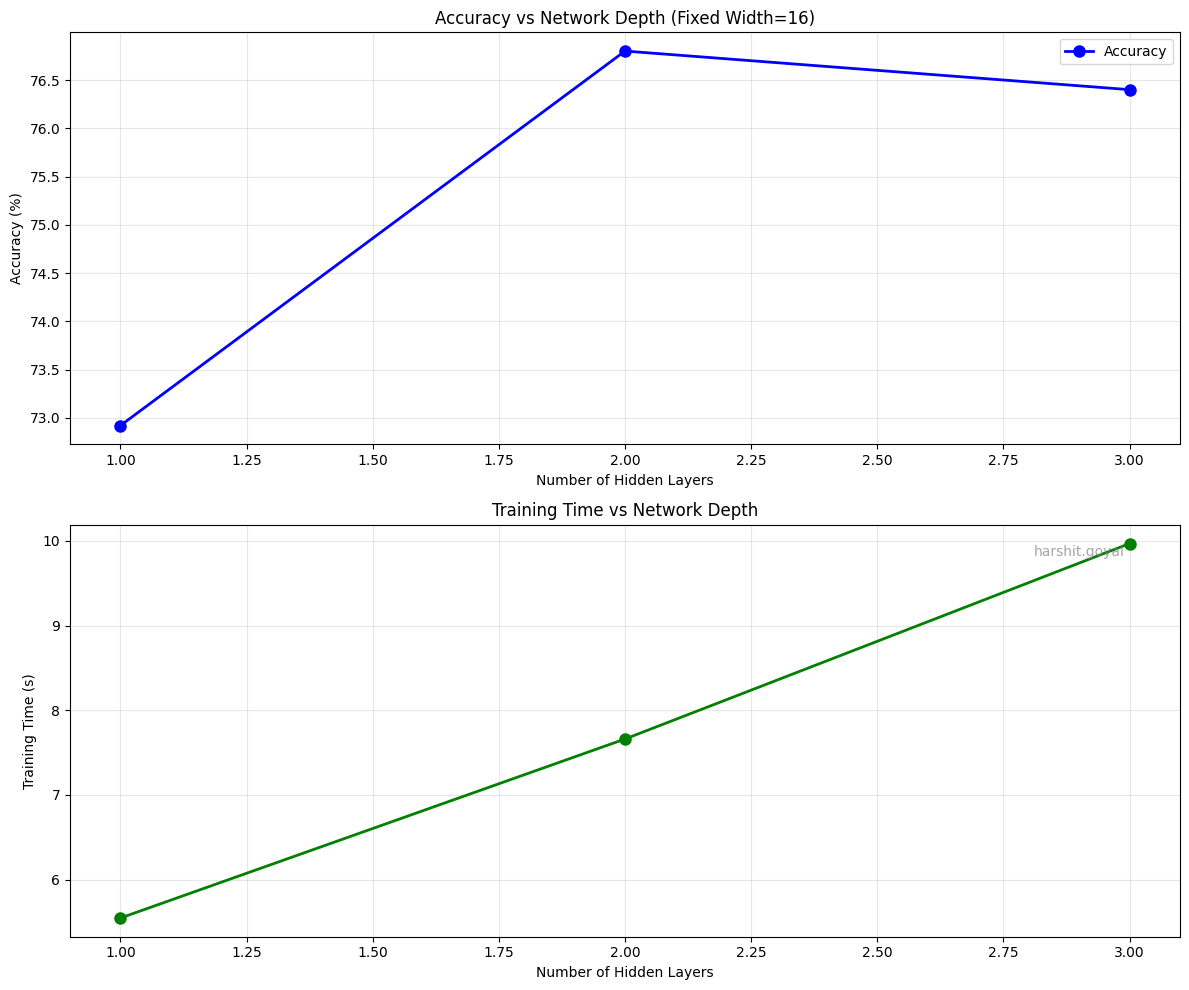


DEPTH ANALYSIS SUMMARY:
Depth 1: Accuracy=72.9%, Time=5.5s
Depth 2: Accuracy=76.8%, Time=7.7s
Depth 3: Accuracy=76.4%, Time=10.0s

Best performing depth: 2 layers with 76.8% accuracy


In [29]:
analyze_depth_performance(models)

### 1.4.3 Width vs Performance Analysis

In [30]:
def analyze_width_performance(results):
    """
    Extract and plot width vs performance metrics from results.
    """
    # Filter results for width experiments (fixed depth = 2)
    width_results = [r for r in results if 'Depth_2' in r['architecture'] and 'Width' in r['architecture']]

    if not width_results:
        print("No width experiment results found!")
        return

    # Extract widths and metrics
    widths = []
    accuracies = []
    training_times = []

    for result in width_results:
        # Extract width from architecture name (e.g., "Depth_2_Width_16")
        width = int(result['architecture'].split('_')[3])
        if width not in widths:  # Ensure only one model per width
            widths.append(width)
            accuracies.append(result['accuracy'])
            training_times.append(result['training_time'])
            print("the arch choosen is ", result['architecture'])

    # Sort by width
    sorted_data = sorted(zip(widths, accuracies, training_times))
    widths, accuracies, training_times = zip(*sorted_data)

    # Create plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Accuracy vs Width
    axes[0].plot(widths, accuracies, 'bo-', linewidth=2, markersize=8, label='Accuracy')
    axes[0].set_xlabel('Number of Neurons per Layer')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Accuracy vs Network Width (Fixed Depth=2)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Training Time vs Width
    axes[1].plot(widths, training_times, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Neurons per Layer')
    axes[1].set_ylabel('Training Time (s)')
    axes[1].set_title('Training Time vs Network Width')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    add_watermark(plt.gca())
    plt.savefig('runs/width_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary
    print("\nWIDTH ANALYSIS SUMMARY:")
    print("="*50)
    for i, width in enumerate(widths):
        print(f"Width {width}: Accuracy={accuracies[i]:.1f}%, Time={training_times[i]:.1f}s")

    # Find best performing width
    best_idx = np.argmax(accuracies)
    print(f"\nBest performing width: {widths[best_idx]} neurons with {accuracies[best_idx]:.1f}% accuracy")

print("Width analysis function ready!")

Width analysis function ready!


the arch choosen is  Depth_2_Width_16
the arch choosen is  Depth_2_Width_8
the arch choosen is  Depth_2_Width_32


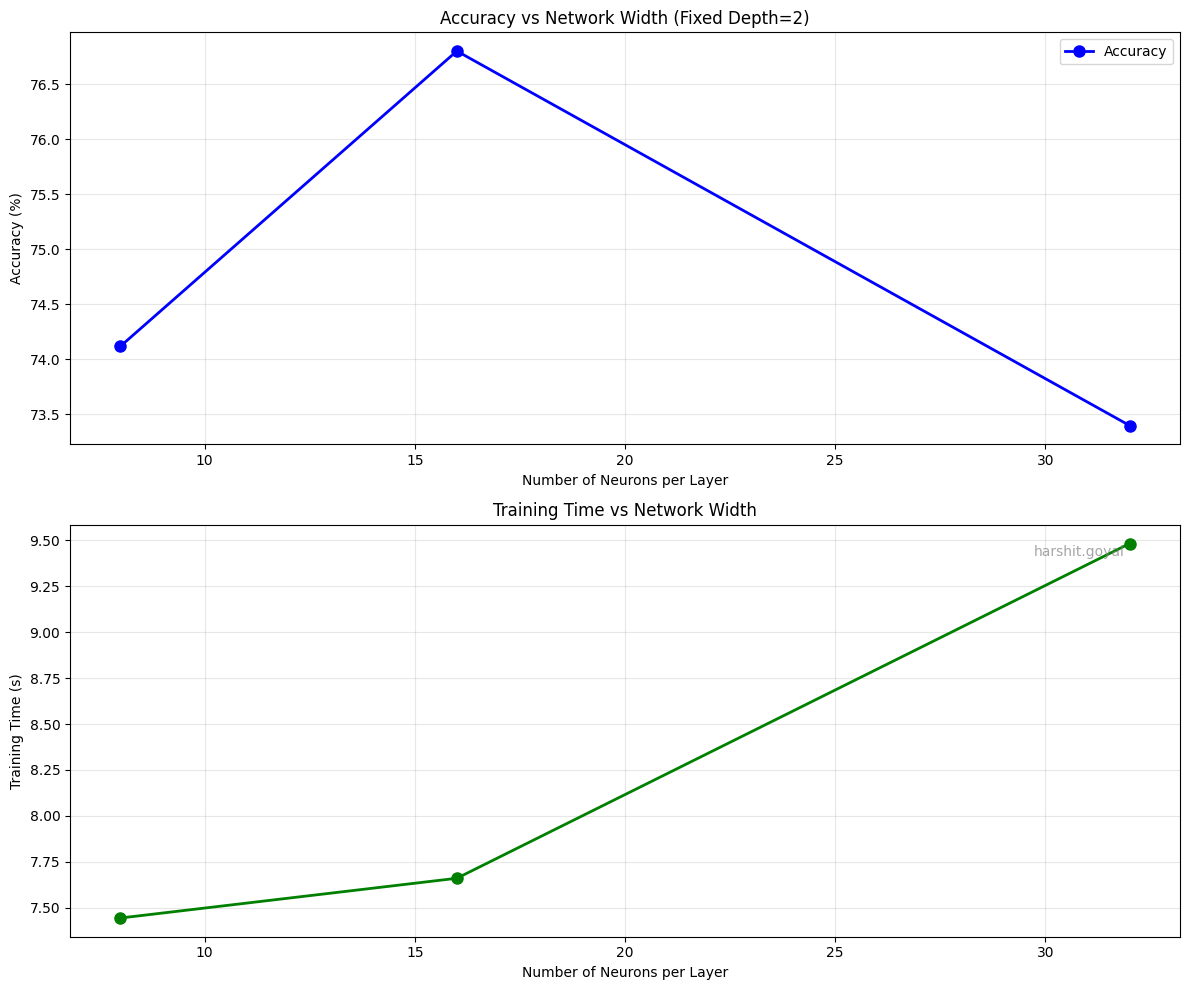


WIDTH ANALYSIS SUMMARY:
Width 8: Accuracy=74.1%, Time=7.4s
Width 16: Accuracy=76.8%, Time=7.7s
Width 32: Accuracy=73.4%, Time=9.5s

Best performing width: 16 neurons with 76.8% accuracy


In [31]:
analyze_width_performance(models)

### 1.4.4 Hyperparameter Experimentation

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def create_hyperparameter_configs():
    """
    Create 6 different hyperparameter configurations for systematic experimentation.
    2 configs each to study: batch size, learning rate, and gradient accumulation.
    Dataset size: 2500 pixels (50x50 image)
    """
    configs = [
        # Batch Size Comparison (fix LR=0.01, grad_acc=1)
        # Small batch for noisy gradients, large batch for stable gradients
        {"batch_size": 8, "learning_rate": 0.01, "grad_accumulation": 1, "name": "SmallBatch_8", "category": "batch_size"},
        {"batch_size": 64, "learning_rate": 0.01, "grad_accumulation": 1, "name": "LargeBatch_64", "category": "batch_size"},
        
        # Learning Rate Comparison (fix batch=16, grad_acc=1)
        # Conservative vs aggressive learning
        {"batch_size": 16, "learning_rate": 0.001, "grad_accumulation": 1, "name": "LowLR_0.001", "category": "learning_rate"},
        {"batch_size": 16, "learning_rate": 0.1, "grad_accumulation": 1, "name": "HighLR_0.1", "category": "learning_rate"},
        
        # Gradient Accumulation Comparison (fix batch=16, LR=0.01)
        # Simulating different effective batch sizes
        {"batch_size": 16, "learning_rate": 0.01, "grad_accumulation": 1, "name": "NoAccum_1", "category": "grad_accumulation"},
        {"batch_size": 16, "learning_rate": 0.01, "grad_accumulation": 8, "name": "Accum_8", "category": "grad_accumulation"},
    ]
    return configs


def run_hyperparameter_experiment():
    """
    Run experiments with different hyperparameters using a fixed architecture.
    """
    import time
    
    configs = create_hyperparameter_configs()
    results = []
    
    print("="*70)
    print("HYPERPARAMETER EXPERIMENT - SYSTEMATIC COMPARISON")
    print("="*70)
    
    for config in configs:
        print(f"\nTesting {config['name']} [{config['category']}]...")
        start_time = time.time()
        
        # Create model with current config
        model = Model([
            LinearLayer(2, 16, ReLU()),
            LinearLayer(16, 16, ReLU()),
            LinearLayer(16, 1, Sigmoid())
        ], bce(), lr=config['learning_rate'])
        
        # Train model using early stopping with current hyperparameters
        total_samples = train_loop_early_stop(
            model, final_data, 
            epochs=5000, 
            batch_size=config['batch_size'], 
            grad_accumulation_steps=config['grad_accumulation'],
            patience=100, 
            relative_loss_threshold=0.001
        )
        
        training_time = time.time() - start_time
        
        # Evaluate accuracy
        accuracy = evaluate_model_accuracy(model, final_data)
        
        # Store results
        result = {
            'config_name': config['name'],
            'category': config['category'],
            'batch_size': config['batch_size'],
            'learning_rate': config['learning_rate'],
            'grad_accumulation': config['grad_accumulation'],
            'effective_batch_size': config['batch_size'] * config['grad_accumulation'],
            'accuracy': accuracy,
            'training_time': training_time,
            'total_samples': total_samples,
        }
        results.append(result)
        
        print(f"Results for {config['name']}:")
        print(f"  Accuracy: {accuracy:.2f}%")
        print(f"  Training Time: {training_time:.2f}s")
        print(f"  Total Samples: {total_samples}")
        print(f"  Effective Batch Size: {result['effective_batch_size']}")
    
    return results


def analyze_hyperparameter_performance(results):
    """
    Analyze and visualize hyperparameter experiment results with category-wise comparisons.
    """
    if not results:
        print("No hyperparameter results found!")
        return
    
    # Group results by category
    batch_size_results = [r for r in results if r['category'] == 'batch_size']
    lr_results = [r for r in results if r['category'] == 'learning_rate']
    grad_acc_results = [r for r in results if r['category'] == 'grad_accumulation']
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # ============ BATCH SIZE COMPARISON ============
    # Accuracy
    ax1 = fig.add_subplot(gs[0, 0])
    names = [r['config_name'] for r in batch_size_results]
    values = [r['batch_size'] for r in batch_size_results]
    accuracies = [r['accuracy'] for r in batch_size_results]
    bars = ax1.bar(values, accuracies, alpha=0.7, color=['#3498db', '#e74c3c'], width=20)
    ax1.set_xlabel('Batch Size')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Batch Size: Impact on Accuracy')
    ax1.set_xticks(values)
    ax1.grid(True, alpha=0.3, axis='y')
    for bar, name, acc in zip(bars, names, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Training Time
    ax2 = fig.add_subplot(gs[0, 1])
    times = [r['training_time'] for r in batch_size_results]
    bars = ax2.bar(values, times, alpha=0.7, color=['#3498db', '#e74c3c'], width=20)
    ax2.set_xlabel('Batch Size')
    ax2.set_ylabel('Training Time (s)')
    ax2.set_title('Batch Size: Impact on Training Time')
    ax2.set_xticks(values)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)
    
    # Samples to Converge
    ax3 = fig.add_subplot(gs[0, 2])
    samples = [r['total_samples'] for r in batch_size_results]
    bars = ax3.bar(values, samples, alpha=0.7, color=['#3498db', '#e74c3c'], width=20)
    ax3.set_xlabel('Batch Size')
    ax3.set_ylabel('Total Samples')
    ax3.set_title('Batch Size: Samples to Converge')
    ax3.set_xticks(values)
    ax3.grid(True, alpha=0.3, axis='y')
    for bar, samp in zip(bars, samples):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{samp/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
    
    # ============ LEARNING RATE COMPARISON ============
    # Accuracy
    ax4 = fig.add_subplot(gs[1, 0])
    names = [r['config_name'] for r in lr_results]
    values = [r['learning_rate'] for r in lr_results]
    accuracies = [r['accuracy'] for r in lr_results]
    bars = ax4.bar(range(len(names)), accuracies, alpha=0.7, color=['#2ecc71', '#f39c12'])
    ax4.set_xlabel('Learning Rate')
    ax4.set_ylabel('Accuracy (%)')
    ax4.set_title('Learning Rate: Impact on Accuracy')
    ax4.set_xticks(range(len(names)))
    ax4.set_xticklabels([f'{v:.3f}' for v in values])
    ax4.grid(True, alpha=0.3, axis='y')
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Training Time
    ax5 = fig.add_subplot(gs[1, 1])
    times = [r['training_time'] for r in lr_results]
    bars = ax5.bar(range(len(names)), times, alpha=0.7, color=['#2ecc71', '#f39c12'])
    ax5.set_xlabel('Learning Rate')
    ax5.set_ylabel('Training Time (s)')
    ax5.set_title('Learning Rate: Impact on Training Time')
    ax5.set_xticks(range(len(names)))
    ax5.set_xticklabels([f'{v:.3f}' for v in values])
    ax5.grid(True, alpha=0.3, axis='y')
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)
    
    # Samples to Converge
    ax6 = fig.add_subplot(gs[1, 2])
    samples = [r['total_samples'] for r in lr_results]
    bars = ax6.bar(range(len(names)), samples, alpha=0.7, color=['#2ecc71', '#f39c12'])
    ax6.set_xlabel('Learning Rate')
    ax6.set_ylabel('Total Samples')
    ax6.set_title('Learning Rate: Samples to Converge')
    ax6.set_xticks(range(len(names)))
    ax6.set_xticklabels([f'{v:.3f}' for v in values])
    ax6.grid(True, alpha=0.3, axis='y')
    for bar, samp in zip(bars, samples):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{samp/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
    
    # ============ GRADIENT ACCUMULATION COMPARISON ============
    # Accuracy
    ax7 = fig.add_subplot(gs[2, 0])
    names = [r['config_name'] for r in grad_acc_results]
    values = [r['grad_accumulation'] for r in grad_acc_results]
    eff_batch = [r['effective_batch_size'] for r in grad_acc_results]
    accuracies = [r['accuracy'] for r in grad_acc_results]
    bars = ax7.bar(range(len(names)), accuracies, alpha=0.7, color=['#9b59b6', '#1abc9c'])
    ax7.set_xlabel('Gradient Accumulation Steps')
    ax7.set_ylabel('Accuracy (%)')
    ax7.set_title('Gradient Accumulation: Impact on Accuracy')
    ax7.set_xticks(range(len(names)))
    ax7.set_xticklabels([f'{v}\n(eff={e})' for v, e in zip(values, eff_batch)])
    ax7.grid(True, alpha=0.3, axis='y')
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Training Time
    ax8 = fig.add_subplot(gs[2, 1])
    times = [r['training_time'] for r in grad_acc_results]
    bars = ax8.bar(range(len(names)), times, alpha=0.7, color=['#9b59b6', '#1abc9c'])
    ax8.set_xlabel('Gradient Accumulation Steps')
    ax8.set_ylabel('Training Time (s)')
    ax8.set_title('Gradient Accumulation: Impact on Training Time')
    ax8.set_xticks(range(len(names)))
    ax8.set_xticklabels([f'{v}\n(eff={e})' for v, e in zip(values, eff_batch)])
    ax8.grid(True, alpha=0.3, axis='y')
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)
    
    # Samples to Converge
    ax9 = fig.add_subplot(gs[2, 2])
    samples = [r['total_samples'] for r in grad_acc_results]
    bars = ax9.bar(range(len(names)), samples, alpha=0.7, color=['#9b59b6', '#1abc9c'])
    ax9.set_xlabel('Gradient Accumulation Steps')
    ax9.set_ylabel('Total Samples')
    ax9.set_title('Gradient Accumulation: Samples to Converge')
    ax9.set_xticks(range(len(names)))
    ax9.set_xticklabels([f'{v}\n(eff={e})' for v, e in zip(values, eff_batch)])
    ax9.grid(True, alpha=0.3, axis='y')
    for bar, samp in zip(bars, samples):
        height = bar.get_height()
        ax9.text(bar.get_x() + bar.get_width()/2., height,
                f'{samp/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Hyperparameter Analysis: Systematic Comparison', fontsize=16, y=0.995)
    add_watermark(plt.gca())    
    plt.savefig('runs/hyperparameter_analysis_detailed.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*100)
    print("HYPERPARAMETER ANALYSIS SUMMARY (Dataset: 2500 pixels, 50x50 image)")
    print("="*100)
    
    # Batch Size Summary
    print("\n1. BATCH SIZE COMPARISON (LR=0.01, GradAcc=1)")
    print("-"*100)
    print(f"{'Config':<20} {'Batch':<8} {'Batches/Epoch':<15} {'Accuracy':<12} {'Time (s)':<12} {'Samples':<15}")
    print("-"*100)
    for r in batch_size_results:
        batches_per_epoch = 2500 / r['batch_size']
        print(f"{r['config_name']:<20} {r['batch_size']:<8} {batches_per_epoch:<15.1f} {r['accuracy']:<12.1f} "
              f"{r['training_time']:<12.1f} {r['total_samples']:<15}")
    
    # Learning Rate Summary
    print("\n2. LEARNING RATE COMPARISON (Batch=16, GradAcc=1)")
    print("-"*100)
    print(f"{'Config':<20} {'LR':<8} {'Accuracy':<12} {'Time (s)':<12} {'Samples':<15}")
    print("-"*100)
    for r in lr_results:
        print(f"{r['config_name']:<20} {r['learning_rate']:<8.3f} {r['accuracy']:<12.1f} "
              f"{r['training_time']:<12.1f} {r['total_samples']:<15}")
    
    # Gradient Accumulation Summary
    print("\n3. GRADIENT ACCUMULATION COMPARISON (Batch=16, LR=0.01)")
    print("-"*100)
    print(f"{'Config':<20} {'GradAcc':<10} {'Eff.Batch':<12} {'Updates/Epoch':<15} {'Accuracy':<12} {'Time (s)':<12} {'Samples':<15}")
    print("-"*100)
    for r in grad_acc_results:
        updates_per_epoch = 2500 / r['effective_batch_size']
        print(f"{r['config_name']:<20} {r['grad_accumulation']:<10} {r['effective_batch_size']:<12} "
              f"{updates_per_epoch:<15.1f} {r['accuracy']:<12.1f} {r['training_time']:<12.1f} {r['total_samples']:<15}")
    
    print("="*100)
    
    # Key Insights
    print("\nKEY INSIGHTS:")
    print("-"*100)
    
    # Batch size insight
    if batch_size_results[0]['accuracy'] > batch_size_results[1]['accuracy']:
        print(f"• Smaller batch size ({batch_size_results[0]['batch_size']}) achieves better accuracy "
              f"({batch_size_results[0]['accuracy']:.1f}% vs {batch_size_results[1]['accuracy']:.1f}%) "
              f"but takes longer to train.")
    else:
        print(f"• Larger batch size ({batch_size_results[1]['batch_size']}) achieves better accuracy "
              f"({batch_size_results[1]['accuracy']:.1f}% vs {batch_size_results[0]['accuracy']:.1f}%) "
              f"and trains faster.")
    
    # Learning rate insight
    best_lr = max(lr_results, key=lambda x: x['accuracy'])
    print(f"• Optimal learning rate is {best_lr['learning_rate']:.3f} achieving {best_lr['accuracy']:.1f}% accuracy.")
    
    # Gradient accumulation insight
    if len(grad_acc_results) >= 2:
        diff_acc = abs(grad_acc_results[0]['accuracy'] - grad_acc_results[1]['accuracy'])
        if diff_acc < 1.0:
            print(f"• Gradient accumulation has minimal impact on accuracy (diff: {diff_acc:.1f}%) "
                  f"but affects training dynamics.")
        else:
            better = grad_acc_results[0] if grad_acc_results[0]['accuracy'] > grad_acc_results[1]['accuracy'] else grad_acc_results[1]
            print(f"• Gradient accumulation of {better['grad_accumulation']} steps performs better "
                  f"with {better['accuracy']:.1f}% accuracy.")
    
    print("="*100)

In [33]:
configs = create_hyperparameter_configs()

In [34]:
res = run_hyperparameter_experiment()

HYPERPARAMETER EXPERIMENT - SYSTEMATIC COMPARISON

Testing SmallBatch_8 [batch_size]...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress:  98%|█████████▊| 4924/5000 [02:03<00:01, 39.83it/s]



Early stopping triggered!
Stopped at epoch: 4925
Loss at epoch 4925: 0.2311
Loss at epoch 4825: 0.2313
Improvement: 0.09% (below threshold of 0.1%)
Results for SmallBatch_8:
  Accuracy: 90.40%
  Training Time: 123.64s
  Total Samples: 12312500
  Effective Batch Size: 8

Testing LargeBatch_64 [batch_size]...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress:  50%|█████     | 2507/5000 [00:09<00:09, 260.17it/s]



Early stopping triggered!
Stopped at epoch: 2508
Loss at epoch 2508: 0.4854
Loss at epoch 2408: 0.4858
Improvement: 0.09% (below threshold of 0.1%)
Results for LargeBatch_64:
  Accuracy: 76.20%
  Training Time: 9.64s
  Total Samples: 6270000
  Effective Batch Size: 64

Testing LowLR_0.001 [learning_rate]...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


...


Early stopping triggered!
Stopped at epoch: 2259
Loss at epoch 2259: 0.2373
Loss at epoch 2159: 0.2375
Improvement: 0.08% (below threshold of 0.1%)
Results for HighLR_0.1:
  Accuracy: 82.80%
  Training Time: 28.63s
  Total Samples: 5647500
  Effective Batch Size: 16

Testing NoAccum_1 [grad_accumulation]...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress: 100%|██████████| 5000/5000 [01:03<00:00, 79.16it/s]



Training completed without early stopping.
Results for NoAccum_1:
  Accuracy: 87.56%
  Training Time: 63.17s
  Total Samples: 12500000
  Effective Batch Size: 16

Testing Accum_8 [grad_accumulation]...
Starting model training...
Early Stopping: Enabled
  - Patience: 100 epochs
  - Relative Loss Threshold: 0.1%


Overall Progress: 100%|██████████| 5000/5000 [00:58<00:00, 85.32it/s]


Training completed without early stopping.
Results for Accum_8:
  Accuracy: 87.56%
  Training Time: 58.60s
  Total Samples: 12500000
  Effective Batch Size: 128


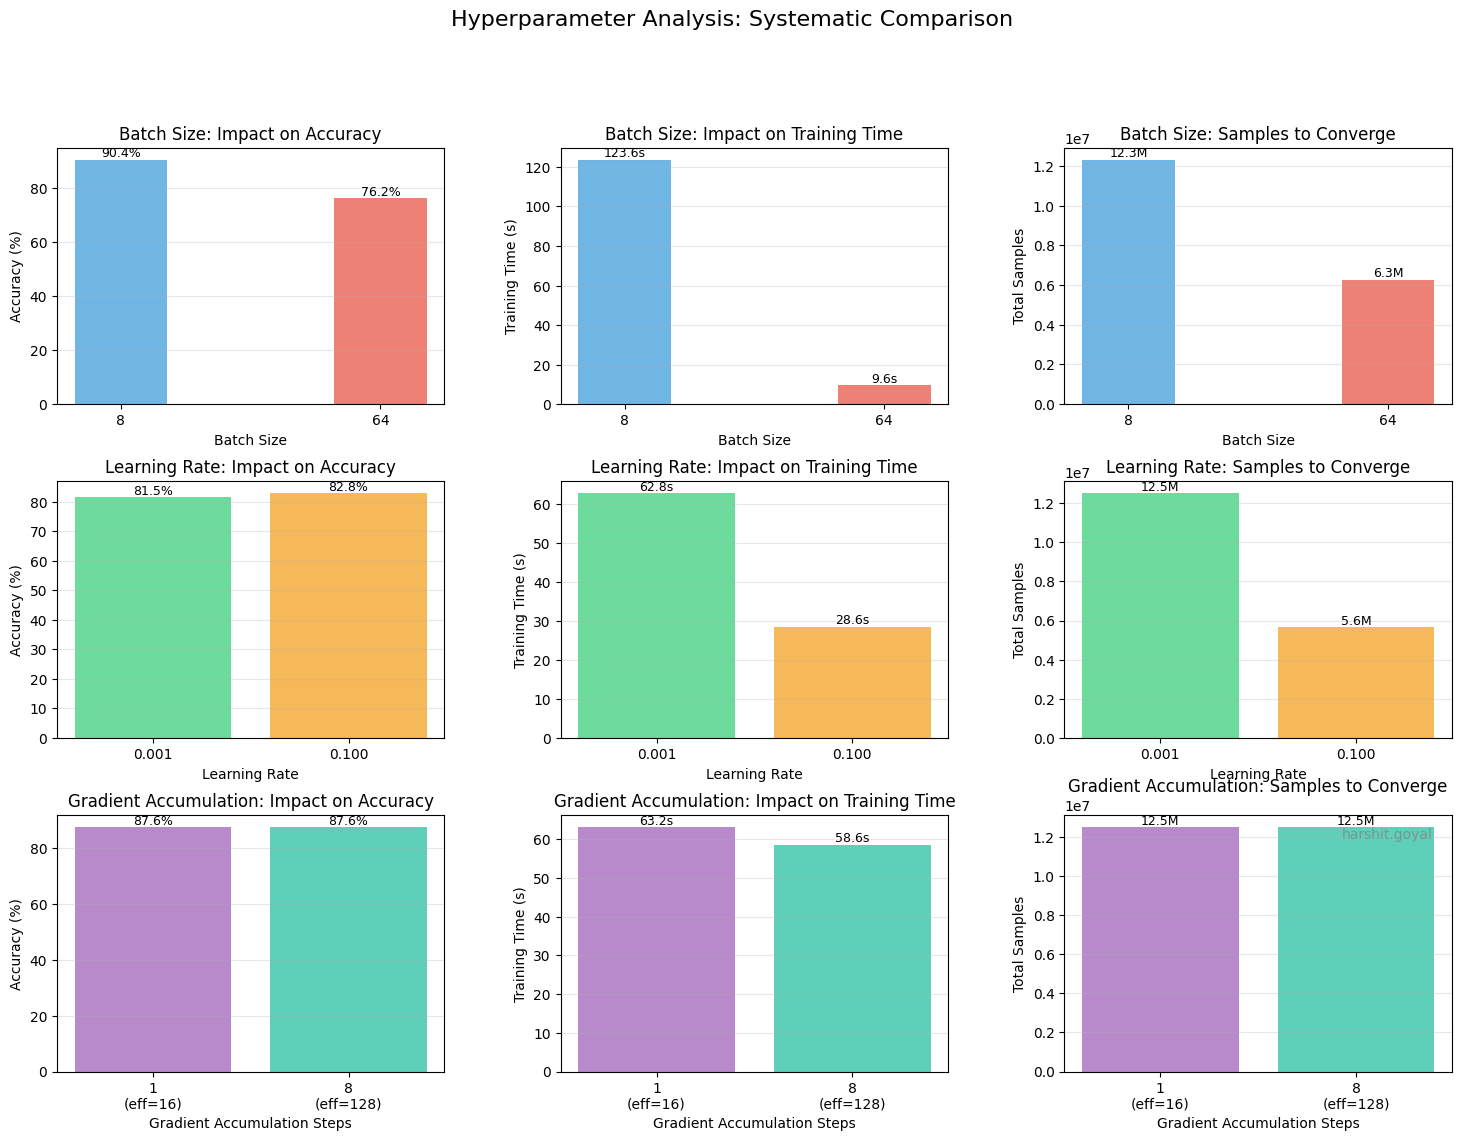


HYPERPARAMETER ANALYSIS SUMMARY (Dataset: 2500 pixels, 50x50 image)

1. BATCH SIZE COMPARISON (LR=0.01, GradAcc=1)
----------------------------------------------------------------------------------------------------
Config               Batch    Batches/Epoch   Accuracy     Time (s)     Samples        
----------------------------------------------------------------------------------------------------
SmallBatch_8         8        312.5           90.4         123.6        12312500       
LargeBatch_64        64       39.1            76.2         9.6          6270000        

2. LEARNING RATE COMPARISON (Batch=16, GradAcc=1)
----------------------------------------------------------------------------------------------------
Config               LR       Accuracy     Time (s)     Samples        
----------------------------------------------------------------------------------------------------
LowLR_0.001          0.001    81.5         62.8         12500000       
HighLR_0.1           

In [35]:
analyze_hyperparameter_performance(res)

## 1.5 Final Challenge

In [36]:
def count_parameters(model):
    """Counts the total number of weights and biases in the model."""
    total_params = 0
    for layer in model.layers:
        if hasattr(layer, 'weights'):
            total_params += layer.weights.size
            total_params += layer.bias.size
    return total_params

In [37]:
def train_loop_in_memory_checkpointing(model, data, epochs, batch_size, patience=100):
    """
    Trains the model, finds the best performing version in memory, and returns its parameters.
    """
    best_loss = float('inf')
    best_model_params = {}
    total_samples = 0
    losses_per_epoch = []
    epochs_no_improve = 0
    
    with tqdm(range(epochs), desc="Training Progress") as pbar:
        for epoch in pbar:
            epoch_loss = 0.0
            
            # Shuffle data each epoch for better training
            np.random.shuffle(data)
            
            num_batches = int(np.ceil(data.shape[0] / batch_size))
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = min((batch_idx + 1) * batch_size, data.shape[0])
                batch_data = data[start_idx:end_idx]
                x_batch = batch_data[:, :-1]
                y_batch = batch_data[:, -1:]

                loss = model.train(x_batch, y_batch)
                epoch_loss += loss
                model.update()
                total_samples += x_batch.shape[0]

            avg_epoch_loss = epoch_loss / num_batches
            losses_per_epoch.append(avg_epoch_loss)
            pbar.set_postfix(loss=f"{avg_epoch_loss:.4f}", best_loss=f"{best_loss:.4f}")

            if avg_epoch_loss < best_loss:
                best_loss = avg_epoch_loss
                epochs_no_improve = 0
                for i, layer in enumerate(model.layers):
                    if hasattr(layer, 'weights'):
                        best_model_params[f"layer_{i}_weights"] = layer.weights.copy()
                        best_model_params[f"layer_{i}_bias"] = layer.bias.copy()
            else:
                epochs_no_improve += 1
            
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
                break
    
    return best_loss, best_model_params, total_samples

In [38]:
# Cell 2: Goal 1 - Systematic Architecture Search to Minimize Model Size

print("="*60)
print(" Goal 1: Searching for the Smallest Model (>91% Accuracy)")
print("="*60)

architectures_to_test = {
    "D1_W8":  [LinearLayer(2, 8, ReLU()), LinearLayer(8, 1, Sigmoid())],
    "D1_W12": [LinearLayer(2, 12, ReLU()), LinearLayer(12, 1, Sigmoid())],
    "D2_W8":  [LinearLayer(2, 8, ReLU()), LinearLayer(8, 8, ReLU()), LinearLayer(8, 1, Sigmoid())],
    "D1_W16": [LinearLayer(2, 16, ReLU()), LinearLayer(16, 1, Sigmoid())],
    "D2_W12": [LinearLayer(2, 12, ReLU()), LinearLayer(12, 12, ReLU()), LinearLayer(12, 1, Sigmoid())],
    "D2_W16": [LinearLayer(2, 16, ReLU()), LinearLayer(16, 16, ReLU()), LinearLayer(16, 1, Sigmoid())],
}

goal1_results = []
optimal_architecture_config = None

for name, layers in architectures_to_test.items():
    print(f"\n--- Training {name} ---")
    model = Model(layers, bce(), lr=0.05) # Using a solid default LR
    
    _, best_params, _ = train_loop_in_memory_checkpointing(
        model, final_data, epochs=5000, batch_size=32, patience=200
    )
    
    # Evaluate the best version of the model
    eval_model = Model(layers, bce())
    if best_params: # Check if training found any best parameters
        for i, layer in enumerate(eval_model.layers):
            if hasattr(layer, 'weights'):
                layer.weights = best_params[f"layer_{i}_weights"]
                layer.bias = best_params[f"layer_{i}_bias"]

    accuracy = evaluate_model_accuracy(eval_model, final_data)
    params_count = count_parameters(eval_model)
    
    result = {'name': name, 'params': params_count, 'accuracy': accuracy, 'layers': layers}
    goal1_results.append(result)
    
    print(f"Result for {name}: Parameters: {params_count}, Best Accuracy: {accuracy:.2f}%")
    
    if accuracy > 91.0:
        print(f"SUCCESS: Target accuracy reached. This is the smallest model found so far.")
        optimal_architecture_config = result
        break

print("\n" + "="*60)
print("Goal 1 Summary")
print("="*60)
if optimal_architecture_config:
    print(f" Optimal Smallest Model: {optimal_architecture_config['name']} "
          f"with {optimal_architecture_config['params']} parameters and {optimal_architecture_config['accuracy']:.2f}% accuracy.")
else:
    print(" No model reached >91% accuracy. Consider adding larger architectures to the test list.")
    # Fallback to the best performing one if none hit the target
    optimal_architecture_config = max(goal1_results, key=lambda x: x['accuracy'])
    print(f"Proceeding with the best found model: {optimal_architecture_config['name']}")

 Goal 1: Searching for the Smallest Model (>91% Accuracy)

--- Training D1_W8 ---


Training Progress: 100%|██████████| 5000/5000 [00:41<00:00, 119.50it/s, best_loss=0.3061, loss=0.3073]


Result for D1_W8: Parameters: 33, Best Accuracy: 86.16%

--- Training D1_W12 ---


Training Progress: 100%|██████████| 5000/5000 [00:42<00:00, 117.62it/s, best_loss=0.2924, loss=0.2955]


Result for D1_W12: Parameters: 49, Best Accuracy: 85.68%

--- Training D2_W8 ---


...

Result for D1_W16: Parameters: 65, Best Accuracy: 85.68%

--- Training D2_W12 ---


Training Progress: 100%|██████████| 5000/5000 [00:49<00:00, 101.72it/s, best_loss=0.2385, loss=0.2415]


Result for D2_W12: Parameters: 205, Best Accuracy: 88.32%

--- Training D2_W16 ---


Training Progress: 100%|██████████| 5000/5000 [00:49<00:00, 100.65it/s, best_loss=0.2522, loss=0.2616]

Result for D2_W16: Parameters: 337, Best Accuracy: 88.60%

Goal 1 Summary
 No model reached >91% accuracy. Consider adding larger architectures to the test list.
Proceeding with the best found model: D2_W16


In [39]:
# Cell: Final Experiment to Surpass 91% Accuracy
print("\n" + "="*60)
print(" Final Attempt: Combining a Wider Model with a Tuned LR")
print("="*60)

# 1. Increase Model Capacity: Move from 16 to 32 neurons in hidden layers
final_architecture = {
    "D2_W64_Tanh": [
        LinearLayer(2, 64, Tanh()),
        LinearLayer(64, 32, Tanh()),
        LinearLayer(32, 1, Sigmoid())
    ]
}

# 2. Define the best baseline hyperparameters and a tuned one
# We know batch_size=8 was best. Let's try a slightly different LR.
final_hyperparams = {
    "lr": 0.02,
    "batch_size": 8
}

# 3. Create and train the model
print(f"Training D2_W64_Tanh with LR={final_hyperparams['lr']} and Batch Size={final_hyperparams['batch_size']}")
final_model = Model(final_architecture["D2_W64_Tanh"], bce(), lr=final_hyperparams['lr'])

# Train with in-memory checkpointing and slightly more patience for the bigger model
best_loss, best_params, samples_seen = train_loop_in_memory_checkpointing(
    final_model, 
    final_data, 
    epochs=5000, 
    batch_size=final_hyperparams['batch_size'], 
    patience=250 
)

# 4. Evaluate the best version of the model found during training
eval_model = Model(final_architecture["D2_W64_Tanh"], bce())
if best_params:
    for i, layer in enumerate(eval_model.layers):
        if hasattr(layer, 'weights'):
            layer.weights = best_params[f"layer_{i}_weights"]
            layer.bias = best_params[f"layer_{i}_bias"]

accuracy = evaluate_model_accuracy(eval_model, final_data)
params_count = count_parameters(eval_model)

print("\n" + "="*60)
print("Final Result")
print("="*60)
print(f"Architecture: D2_W64_Tanh")
print(f"Parameters: {params_count}")
print(f"Samples Seen to Converge: {samples_seen}")
if accuracy > 91.0:
    print(f" SUCCESS! Final Accuracy: {accuracy:.2f}%")
    optimal_architecture_config={
        'name': "D2_W64_Tanh",
        'params': params_count,
        'accuracy': accuracy,
        'layers': final_architecture["D2_W64_Tanh"]
    }
else:
    print(f" Target not reached. Final Accuracy: {accuracy:.2f}%. Consider an even wider model (e.g., 64 neurons) or a deeper one.")


 Final Attempt: Combining a Wider Model with a Tuned LR
Training D2_W64_Tanh with LR=0.02 and Batch Size=8


Training Progress: 100%|██████████| 5000/5000 [02:38<00:00, 31.47it/s, best_loss=0.1875, loss=0.1881]


Final Result
Architecture: D2_W64_Tanh
Parameters: 2305
Samples Seen to Converge: 12500000
 SUCCESS! Final Accuracy: 91.80%



 VISUALIZING THE BEST MODEL'S PERFORMANCE
Generating prediction map for visualization...


Predicting pixels: 100%|██████████| 50/50 [00:00<00:00, 2032.32it/s]


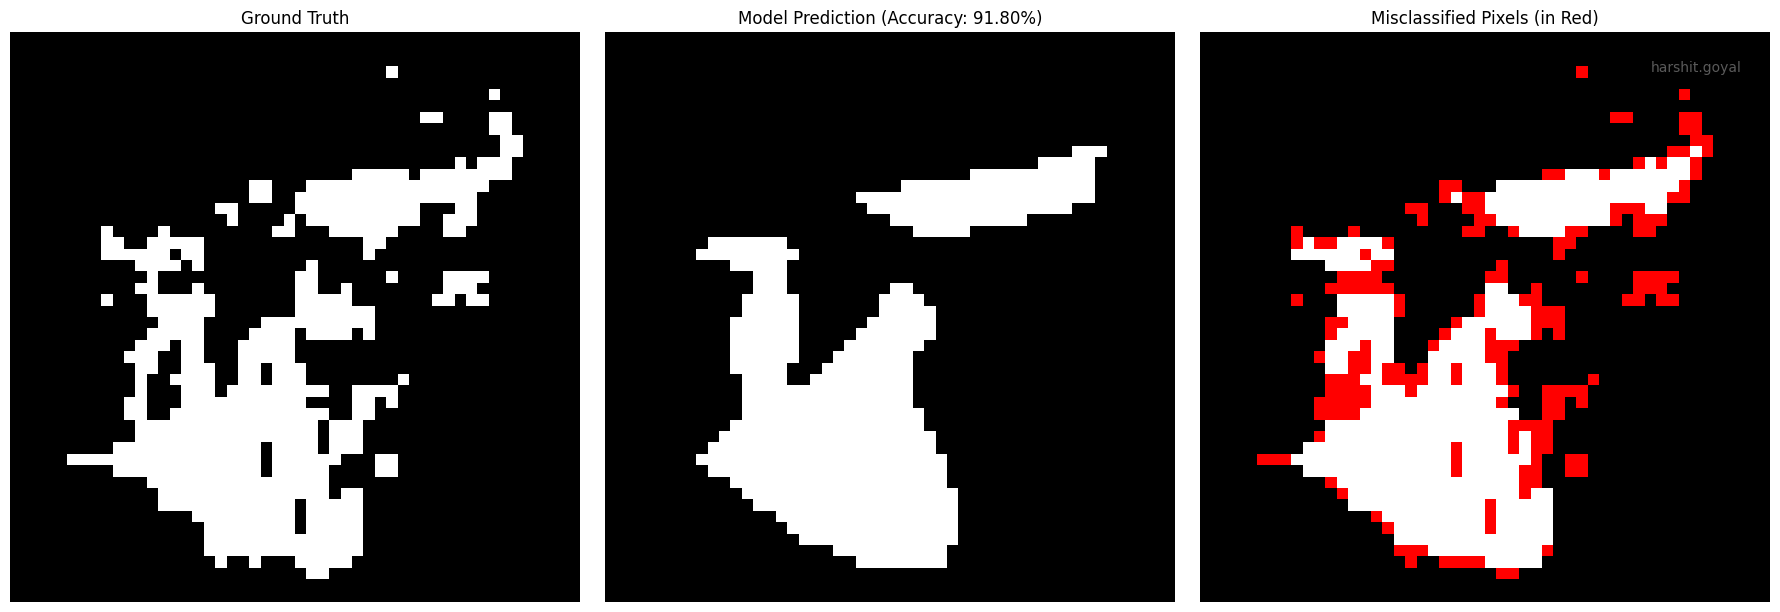

In [40]:
# Cell: Visualization of the Best Model's Predictions

print("\n" + "="*60)
print(" VISUALIZING THE BEST MODEL'S PERFORMANCE")
print("="*60)

# The 'eval_model' variable should still hold the best model from the previous cell.
best_model_to_visualize = eval_model

# Get the height and width from the dataset object
height, width = dataset_obj.height, dataset_obj.width

# 1. Create the model's prediction map
prediction_map = np.zeros((height, width))
print("Generating prediction map for visualization...")
for y in tqdm(range(height), desc="Predicting pixels"):
    for x in range(width):
        # Normalize coordinates for the model
        norm_y = y / height
        norm_x = x / width
        coords = np.array([[norm_y, norm_x]])
        prediction = best_model_to_visualize.predict(coords)
        prediction_map[y, x] = 1 if prediction[0, 0] > 0.5 else 0

# 2. Get the ground truth map directly from the dataset object
ground_truth_map = dataset_obj.img_arr

# 3. Create the overlay map to show misclassified pixels
# Start with a 3-channel (RGB) version of the ground truth
# Where 0 (black) becomes [0,0,0] and 1 (white) becomes [1,1,1]
overlay_map = np.stack([ground_truth_map]*3, axis=-1).astype(float)

# Find the locations of errors
errors = (prediction_map != ground_truth_map)

# Color the errors bright red on the overlay map
# Where an error occurred (errors == True), set the pixel to red [1, 0, 0]
overlay_map[errors] = [1.0, 0.0, 0.0]

# --- Display the three images ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Image 1: Ground Truth
axes[0].imshow(ground_truth_map, cmap='gray')
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# Image 2: Model's Prediction
axes[1].imshow(prediction_map, cmap='gray')
axes[1].set_title(f'Model Prediction (Accuracy: {accuracy:.2f}%)')
axes[1].axis('off')

# Image 3: Error Map Overlay
axes[2].imshow(overlay_map)
axes[2].set_title('Misclassified Pixels (in Red)')
axes[2].axis('off')

plt.tight_layout()
add_watermark(plt.gca())
plt.show()

So changing to tanh lead us to achieve 91.2 with ~2300 params may be we might remove some and be ablee to have > 91 with less params.

Idea to reduce can be slightly reducing some widths etc and may be splitting the neurons in more layers so that we can have more non linearities etc lets try with that

In [41]:
# Cell: Searching for the Model with Minimum Parameters

print("\n" + "="*60)
print(" Goal 1 Refined: Finding the Smallest Model >91% Accuracy")
print("="*60)

# Architectures to test, ordered from most likely to succeed to least
smaller_architectures = {
    "D2_W48_24_Tanh": [
        LinearLayer(2, 48, Tanh()),
        LinearLayer(48, 24, Tanh()),
        LinearLayer(24, 1, Sigmoid())
    ],
    "D2_W32_16_Tanh": [
        LinearLayer(2, 32, Tanh()),
        LinearLayer(32, 16, Tanh()),
        LinearLayer(16, 1, Sigmoid())
    ],
    "D3_W16_Tanh": [
        LinearLayer(2, 16, Tanh()),
        LinearLayer(16, 16, Tanh()),
        LinearLayer(16, 16, Tanh()),
        LinearLayer(16, 1, Sigmoid())
    ],
}

# Use the hyperparameters that have proven effective
lr = 0.02
batch_size = 8
best_small_model = None

for name, layers in smaller_architectures.items():
    print(f"\n--- Testing smaller architecture: {name} ---")
    model = Model(layers, bce(), lr=lr)
    
    _, best_params, _ = train_loop_in_memory_checkpointing(
        model, final_data, epochs=5000, batch_size=batch_size, patience=300
    )
    
    eval_model = Model(layers, bce())
    if best_params:
        for i, layer in enumerate(eval_model.layers):
            if hasattr(layer, 'weights'):
                layer.weights = best_params[f"layer_{i}_weights"]
                layer.bias = best_params[f"layer_{i}_bias"]

    accuracy = evaluate_model_accuracy(eval_model, final_data)
    params_count = count_parameters(eval_model)
    
    print(f"Result for {name}: Parameters: {params_count}, Best Accuracy: {accuracy:.2f}%")
    
    if accuracy > 91.0:
        print(f" SUCCESS: This model still meets the target!")
        # Since we are testing in decreasing size, this is our new best candidate
        best_small_model = {'name': name, 'params': params_count, 'accuracy': accuracy, 'model': eval_model}
    else:
        print(f" Target not reached. The previous model was the smallest.")

print("\n" + "="*60)
print("Final Result for Goal 1: Minimum Model Size")
print("="*60)
if best_small_model:
    print(f"The smallest model to achieve >91% accuracy is: {best_small_model['name']}")
    print(f"It has {best_small_model['params']} parameters and achieved {best_small_model['accuracy']:.2f}% accuracy.")
else:
    # This will happen if your original 2305-param model was already the smallest
    print("The model that first achieved >91% accuracy (2305 parameters) appears to be the smallest.")


 Goal 1 Refined: Finding the Smallest Model >91% Accuracy

--- Testing smaller architecture: D2_W48_24_Tanh ---


Training Progress: 100%|██████████| 5000/5000 [02:25<00:00, 34.27it/s, best_loss=0.1899, loss=0.1904]


Result for D2_W48_24_Tanh: Parameters: 1345, Best Accuracy: 91.84%
 SUCCESS: This model still meets the target!

--- Testing smaller architecture: D2_W32_16_Tanh ---


Training Progress: 100%|██████████| 5000/5000 [02:19<00:00, 35.82it/s, best_loss=0.1948, loss=0.1956]


Result for D2_W32_16_Tanh: Parameters: 641, Best Accuracy: 90.68%
 Target not reached. The previous model was the smallest.

--- Testing smaller architecture: D3_W16_Tanh ---


Training Progress: 100%|██████████| 5000/5000 [02:42<00:00, 30.81it/s, best_loss=0.1539, loss=0.1551]

Result for D3_W16_Tanh: Parameters: 609, Best Accuracy: 93.60%
 SUCCESS: This model still meets the target!

Final Result for Goal 1: Minimum Model Size
The smallest model to achieve >91% accuracy is: D3_W16_Tanh
It has 609 parameters and achieved 93.60% accuracy.


So clearly even reducing the number of params help us infact here we are even beating the 91 % accuracy with a huge margin of 2% as we increase the layers and it has the least number of params till now. 

The reason for this can be that with more layers we are able to learn more complex functions and also the number of non linearities increase which helps us in learning complex functions.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

def display_model_performance_maps(model_to_visualize, dataset_obj):
    """
    Generates and displays a side-by-side comparison of a model's performance.

    This function creates three plots:
    1. The Ground Truth map from the original data.
    2. The model's Predicted Map for the entire pixel grid.
    3. An Error Map showing misclassified pixels in red overlaid on the ground truth.

    Args:
        model_to_visualize (Model): A trained instance of your Model class.
        dataset_obj (Dataset): The dataset object containing the original image data.
    """
    print("\n" + "="*60)
    print(" VISUALIZING MODEL PERFORMANCE")
    print("="*60)

    # Get the height and width from the dataset object
    height, width = dataset_obj.height, dataset_obj.width

    # 1. Create the model's prediction map
    prediction_map = np.zeros((height, width))
    print("Generating prediction map for visualization...")
    for y in tqdm(range(height), desc="Predicting pixels"):
        for x in range(width):
            # Normalize coordinates for the model
            norm_y = y / height
            norm_x = x / width
            coords = np.array([[norm_y, norm_x]])
            prediction = model_to_visualize.predict(coords)
            prediction_map[y, x] = 1 if prediction[0, 0] > 0.5 else 0

    # 2. Get the ground truth map directly from the dataset object
    ground_truth_map = dataset_obj.img_arr
    
    # Calculate accuracy for the title
    accuracy = (np.sum(prediction_map == ground_truth_map) / (height * width)) * 100

    # 3. Create the overlay map to show misclassified pixels
    # Start with a 3-channel (RGB) version of the ground truth
    overlay_map = np.stack([ground_truth_map]*3, axis=-1).astype(float)

    # Find the locations of errors
    errors = (prediction_map != ground_truth_map)

    # Color the errors bright red on the overlay map
    overlay_map[errors] = [1.0, 0.0, 0.0]  # Set error pixels to red [R, G, B]

    # --- Display the three images ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Image 1: Ground Truth
    axes[0].imshow(ground_truth_map, cmap='gray')
    axes[0].set_title('Ground Truth')
    axes[0].axis('off')

    # Image 2: Model's Prediction
    axes[1].imshow(prediction_map, cmap='gray')
    axes[1].set_title(f'Model Prediction (Accuracy: {accuracy:.2f}%)')
    axes[1].axis('off')

    # Image 3: Error Map Overlay
    axes[2].imshow(overlay_map)
    axes[2].set_title('Misclassified Pixels (in Red)')
    axes[2].axis('off')

    plt.tight_layout()
    add_watermark(plt.gca())
    plt.show()

In [43]:
best_model = best_small_model['model']


 VISUALIZING MODEL PERFORMANCE
Generating prediction map for visualization...


Predicting pixels: 100%|██████████| 50/50 [00:00<00:00, 2083.22it/s]


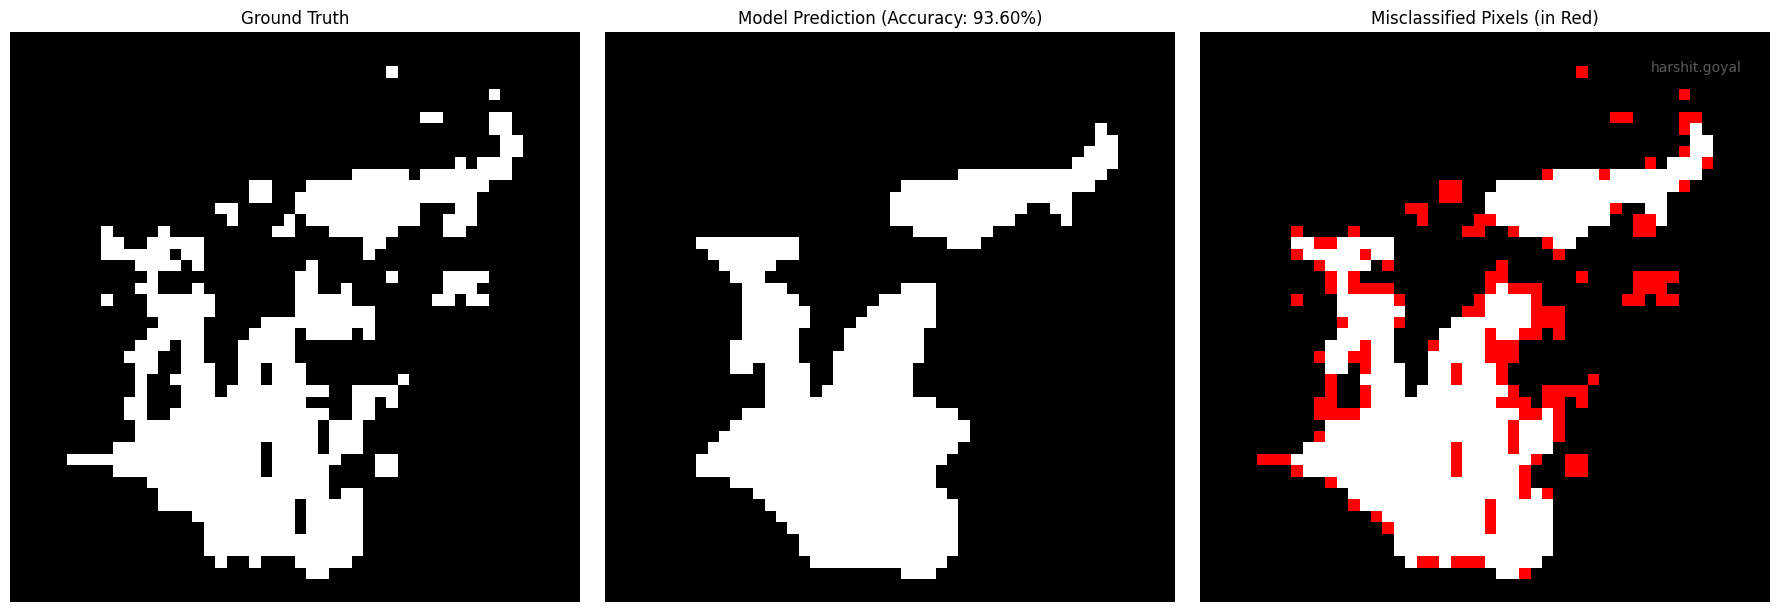

In [44]:
display_model_performance_maps(best_model,dataset_obj)

#### Minimizing training samples

In [45]:
# Cell 1: Setup for Goal 2 Experiment

print("\n" + "="*60)
print(" Goal 2: Setting up to Minimize Training Samples")
print("="*60)

# 1. Define the best architecture found in Goal 1
# This is the D3_W16_Tanh model with 609 parameters.
best_architecture_layers = [
    LinearLayer(2, 16, Tanh()),
    LinearLayer(16, 16, Tanh()),
    LinearLayer(16, 16, Tanh()),
    LinearLayer(16, 1, Sigmoid())
]

# 2. Create hyperparameter configurations to test
# We'll test different learning rates and batch sizes to see which converges fastest.
# We know that lr=0.02 and batch_size=8 works, so we'll test around those values.
hyperparam_configs = {
    "LR_0.05_BS_8":  {"lr": 0.05, "batch_size": 8},
    "LR_0.02_BS_8":  {"lr": 0.02, "batch_size": 8},
    "LR_0.01_BS_8":  {"lr": 0.01, "batch_size": 8},
    "LR_0.02_BS_16": {"lr": 0.02, "batch_size": 16},
}

print("Best architecture defined: D3_W16_Tanh")
print(f"Created {len(hyperparam_configs)} hyperparameter configurations to test.")


 Goal 2: Setting up to Minimize Training Samples
Best architecture defined: D3_W16_Tanh
Created 4 hyperparameter configurations to test.


In [46]:
# Cell 2: Run and Analyze the Hyperparameter Experiment

print("\n" + "="*60)
print(" Goal 2: Searching for the Fastest Training Configuration")
print("="*60)

goal2_successful_runs = []

for name, config in hyperparam_configs.items():
    print(f"\n--- Training with configuration: {name} ---")
    
    # Re-initialize the model for each run with the best architecture
    model = Model(best_architecture_layers, bce(), lr=config['lr'])
    
    # Train the model and get the total samples seen
    _, best_params, samples_seen = train_loop_in_memory_checkpointing(
        model, final_data,
        epochs=5000, # High epoch count to ensure convergence
        batch_size=config['batch_size'],
        patience=300 # A reasonable patience
    )
    
    # Evaluate the best version of the model from this run
    eval_model = Model(best_architecture_layers, bce())
    if best_params:
        for i, layer in enumerate(eval_model.layers):
            if hasattr(layer, 'weights'):
                layer.weights = best_params[f"layer_{i}_weights"]
                layer.bias = best_params[f"layer_{i}_bias"]
    
    accuracy = evaluate_model_accuracy(eval_model, final_data)
    
    print(f"Result for {name}: Accuracy: {accuracy:.2f}%, Samples to Converge: {samples_seen}")

    # Only consider runs that successfully beat the target
    if accuracy > 91.0:
        goal2_successful_runs.append({
            'name': name,
            'lr': config['lr'],
            'batch_size': config['batch_size'],
            'samples_seen': samples_seen,
            'accuracy': accuracy
        })

# --- Analyze the Results ---
print("\n" + "="*60)
print("Goal 2 Results Summary")
print("="*60)

if not goal2_successful_runs:
    print(" No configuration reached the target accuracy. Consider trying different hyperparameters.")
else:
    # Find the best result (the one with the minimum samples seen)
    most_efficient_config = min(goal2_successful_runs, key=lambda x: x['samples_seen'])
    
    print(f"{'Configuration':<15} | {'LR':<8} | {'Batch Size':<12} | {'Accuracy':<12} | {'Samples Seen':<15}")
    print("-"*80)
    for res in goal2_successful_runs:
        print(f"{res['name']:<15} | {res['lr']:<8.3f} | {res['batch_size']:<12} | {res['accuracy']:<12.2f}% | {res['samples_seen']:<15}")
    
    print("\n" + "-"*80)
    print(" Optimal Configuration for Fastest Convergence:")
    print(f"   - Configuration Name: {most_efficient_config['name']}")
    print(f"   - Learning Rate: {most_efficient_config['lr']}, Batch Size: {most_efficient_config['batch_size']}")
    print(f"   - Minimum Samples to Converge: {most_efficient_config['samples_seen']}")


 Goal 2: Searching for the Fastest Training Configuration

--- Training with configuration: LR_0.05_BS_8 ---


Training Progress: 100%|██████████| 5000/5000 [02:38<00:00, 31.48it/s, best_loss=0.0979, loss=0.1022]


Result for LR_0.05_BS_8: Accuracy: 95.96%, Samples to Converge: 12500000

--- Training with configuration: LR_0.02_BS_8 ---


Training Progress:  93%|█████████▎| 4626/5000 [02:26<00:11, 31.51it/s, best_loss=0.0795, loss=0.0810]



Early stopping triggered at epoch 4627.
Result for LR_0.02_BS_8: Accuracy: 96.80%, Samples to Converge: 11567500

--- Training with configuration: LR_0.01_BS_8 ---


Training Progress:  20%|██        | 1025/5000 [00:32<02:06, 31.43it/s, best_loss=0.0768, loss=0.0785]



Early stopping triggered at epoch 1026.
Result for LR_0.01_BS_8: Accuracy: 96.32%, Samples to Converge: 2565000

--- Training with configuration: LR_0.02_BS_16 ---


Training Progress:  28%|██▊       | 1377/5000 [00:25<01:06, 54.70it/s, best_loss=0.0749, loss=0.0764]


Early stopping triggered at epoch 1378.
Result for LR_0.02_BS_16: Accuracy: 96.88%, Samples to Converge: 3445000

Goal 2 Results Summary
Configuration   | LR       | Batch Size   | Accuracy     | Samples Seen   
--------------------------------------------------------------------------------
LR_0.05_BS_8    | 0.050    | 8            | 95.96       % | 12500000       
LR_0.02_BS_8    | 0.020    | 8            | 96.80       % | 11567500       
LR_0.01_BS_8    | 0.010    | 8            | 96.32       % | 2565000        
LR_0.02_BS_16   | 0.020    | 16           | 96.88       % | 3445000        

--------------------------------------------------------------------------------
 Optimal Configuration for Fastest Convergence:
   - Configuration Name: LR_0.01_BS_8
   - Learning Rate: 0.01, Batch Size: 8
   - Minimum Samples to Converge: 2565000


Check output here
https://iiithydstudents-my.sharepoint.com/:f:/g/personal/harshit_goyal_students_iiit_ac_in/Epzi_DJqdWJOr0-3zlGD_YYBvLFEDwpf1czqZ5RyQzu0gQ?e=X1EaHh